In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import plotly.graph_objects as go

## Cargamos el dataset explorado

In [2]:
data = pd.read_parquet('spotify_dataset_explorado.parquet')

data

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,...,instrumentalness,liveness,valence,tempo,time_signature,track_genre,exito_musical,track_genre_encoded,n_artistas,energia_bailable
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,0,0.676,0.4610,1,...,0.000001,0.3580,0.7150,87.917000,4,acoustic,1,0,1,0.311636
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,0,0.420,0.1660,1,...,0.000006,0.1010,0.2670,77.488998,4,acoustic,0,0,1,0.069720
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,0,0.438,0.3590,0,...,0.000000,0.1170,0.1200,76.332001,4,acoustic,0,0,2,0.157242
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,0,0.266,0.0596,0,...,0.000071,0.1320,0.1430,181.740005,3,acoustic,1,0,1,0.015854
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,0,0.618,0.4430,2,...,0.000000,0.0829,0.1670,119.948997,4,acoustic,1,0,1,0.273774
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113544,2C3TZjDRiAzdyViavDJ217,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Sleep My Little Boy,21,384999,0,0.172,0.2350,5,...,0.928000,0.0863,0.0339,125.995003,5,world-music,0,113,1,0.040420
113545,1hIz5L4IB9hN3WRYPOCGPw,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Water Into Light,22,385000,0,0.174,0.1170,0,...,0.976000,0.1050,0.0350,85.238998,4,world-music,0,113,1,0.020358
113546,6x8ZfSoqDjuNa5SVP5QjvX,Cesária Evora,Best Of,Miss Perfumado,22,271466,0,0.629,0.3290,0,...,0.000000,0.0839,0.7430,132.378006,4,world-music,0,113,1,0.206941
113547,2e6sXL2bYv4bSz6VTdnfLs,Michael W. Smith,Change Your World,Friends,41,283893,0,0.587,0.5060,7,...,0.000000,0.2700,0.4130,135.960007,4,world-music,0,113,1,0.297022


### Estandarización de audio features (variables numéricas)

Aplicamos StandardScaler a las nueve audio features. Centra en media 0 y elimina las unidades de medida.

In [3]:
cols_escalar = [
    'danceability', 'energy', 'valence', 'acousticness',
    'instrumentalness', 'liveness', 'speechiness',
    'loudness', 'tempo', 'duration_ms'
]

scaler = StandardScaler()
data[cols_escalar] = scaler.fit_transform(data[cols_escalar])
data

# Verificación: media ~0 y std ~1 en todas las columnas
# print("=== Verificación del escalado ===")
# print(data[cols_escalar].describe().loc[['mean', 'std']].round(3))

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,...,instrumentalness,liveness,valence,tempo,time_signature,track_genre,exito_musical,track_genre_encoded,n_artistas,energia_bailable
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,0.024289,0,0.628394,-0.721328,1,...,-0.503538,0.758094,0.928983,-1.142994,4,acoustic,1,0,1,0.311636
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,-0.737425,0,-0.847891,-1.896382,1,...,-0.503524,-0.591264,-0.799395,-1.490909,4,acoustic,0,0,1,0.069720
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,-0.162155,0,-0.744089,-1.127618,0,...,-0.503542,-0.507257,-1.366520,-1.529510,4,acoustic,0,0,2,0.157242
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,-0.245726,0,-1.735968,-2.320198,0,...,-0.503313,-0.428501,-1.277786,1.987276,3,acoustic,1,0,1,0.015854
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,-0.274670,0,0.293923,-0.793026,2,...,-0.503542,-0.686296,-1.185194,-0.074292,4,acoustic,1,0,1,0.273774
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113544,2C3TZjDRiAzdyViavDJ217,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Sleep My Little Boy,21,1.474615,0,-2.278041,-1.621539,5,...,2.497600,-0.668445,-1.698692,0.127424,5,world-music,0,113,1,0.040420
113545,1hIz5L4IB9hN3WRYPOCGPw,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Water Into Light,22,1.474624,0,-2.266507,-2.091561,0,...,2.652832,-0.570262,-1.694449,-1.232341,4,world-music,0,113,1,0.020358
113546,6x8ZfSoqDjuNa5SVP5QjvX,Cesária Evora,Best Of,Miss Perfumado,22,0.407702,0,0.357357,-1.247115,0,...,-0.503542,-0.681046,1.037007,0.340384,4,world-music,0,113,1,0.206941
113547,2e6sXL2bYv4bSz6VTdnfLs,Michael W. Smith,Change Your World,Friends,41,0.524483,0,0.115154,-0.542082,7,...,-0.503542,0.296057,-0.236129,0.459892,4,world-music,0,113,1,0.297022


## Selección de variables que entran al clustering

In [4]:
cols_clustering = [
    'danceability', 'acousticness', 'instrumentalness', 'liveness', 'energy',
    'valence', 'speechiness',
    'loudness', 'tempo', 'duration_ms'
]

X = data[cols_clustering]

# Verificación del escalado
# print("=== Verificación del escalado ===")
# print(X.describe().loc[['mean', 'std']].round(3))
# print(f"\nMatriz de clustering: {X.shape}")

res: Media 0 y std 1 en todas las columnas. Matriz de clustering 113.549 × 9

## Método del codo

k=2 → inercia: 916632
k=3 → inercia: 823371
k=4 → inercia: 754444
k=5 → inercia: 691753
k=6 → inercia: 639592
k=7 → inercia: 590211
k=8 → inercia: 562393
k=9 → inercia: 535350
k=10 → inercia: 509735


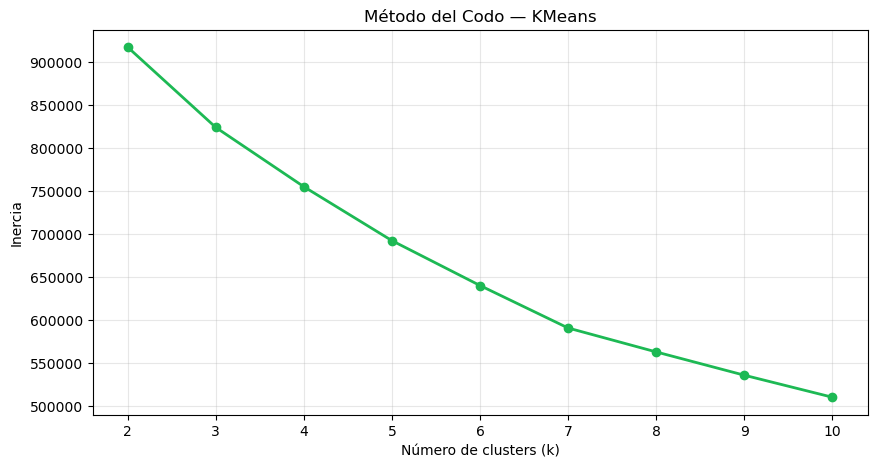

In [5]:
# Probamos k entre 2 y 10 y medimos la inercia (suma de distancias
# al centroide). Buscamos el punto donde la curva "dobla".

inercias = []
rango_k = range(2, 11)

for k in rango_k:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    inercias.append(kmeans.inertia_)
    print(f"k={k} → inercia: {kmeans.inertia_:.0f}")

# Gráfico del codo
plt.figure(figsize=(10, 5))
plt.plot(rango_k, inercias, marker='o', color='#1DB954', linewidth=2)
plt.title('Método del Codo — KMeans')
plt.xlabel('Número de clusters (k)')
plt.ylabel('Inercia')
plt.xticks(rango_k)
plt.grid(True, alpha=0.3)
plt.show()

En el análisis cluster, en el método del codo la curva empieza a suavizarse un poco en el 7 (k=7), la pendiente deja de ser tan abrupta, es casi la mitad de varianza intra cluster. Con K=7 saldrán mejores grupos.

Pero con el codo solo no es suficiente para decidir. Por eso ahora calculamos el coeficiente de silhouette, que es el segundo método. Este nos da una puntuación entre -1 y 1 para cada k, y elegimos el que tenga puntuación más alta.

## Coeficiente de Silhouette 

k=2 → silhouette: 0.2499
k=3 → silhouette: 0.1556
k=4 → silhouette: 0.1616
k=5 → silhouette: 0.1662
k=6 → silhouette: 0.1662
k=7 → silhouette: 0.1767
k=8 → silhouette: 0.1592
k=9 → silhouette: 0.1602
k=10 → silhouette: 0.1640


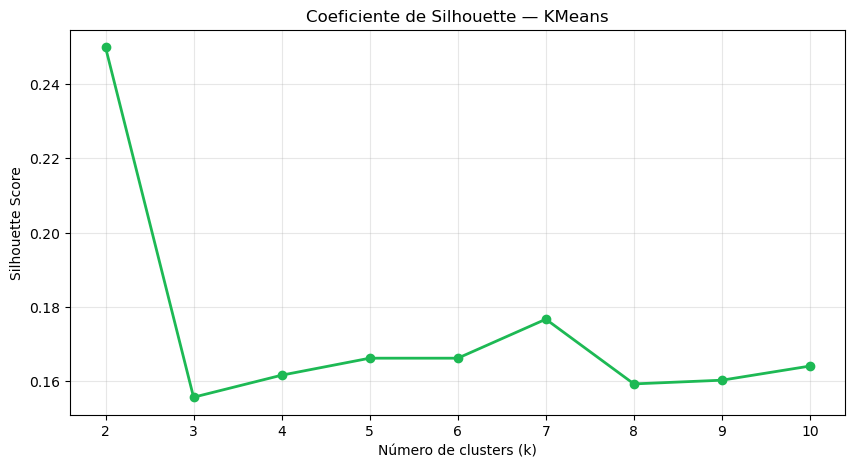

In [6]:
# Mide qué tan bien separados están los grupos.
# Valor cercano a 1 = grupos bien separados.
# Valor cercano a 0 = grupos solapados.

from sklearn.metrics import silhouette_score

silhouettes = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X)
    score = silhouette_score(X, labels, sample_size=10000, random_state=42)
    silhouettes.append(score)
    print(f"k={k} → silhouette: {score:.4f}")

# Gráfico
plt.figure(figsize=(10, 5))
plt.plot(range(2, 11), silhouettes, marker='o', color='#1DB954', linewidth=2)
plt.title('Coeficiente de Silhouette — KMeans')
plt.xlabel('Número de clusters (k)')
plt.ylabel('Silhouette Score')
plt.xticks(range(2, 11))
plt.grid(True, alpha=0.3)
plt.show()

Entre 7 y 9 tiene más sentido, porque la silueta media indica el grado de cohesión de los grupos formados. El más alto es el 7 y a partir de ahí ya desciende el grado de silueta media. Si lo comparamos con el método del codo parece que ambos indican que mejor el 7 . Siempre hay que buscar el coeficiente mayor, aunque en este caso no parece una estructura muy estable la que ha encontrado.

La silueta nos dice cómo de bien está asignado un individuo a un grupo. El pico que tenemos en 7  nos dice que tomando 7 grupos los grupos parecen más estables, os individuos más parecidos dentro de cada grupo y distintos entre los grupos en principio. Quiere decir que los individuos están más o menos bien asignados a los grupos.



## Entrenamiento de KMeans con k=7 

In [7]:
kmeans = KMeans(n_clusters=7, random_state=42, n_init=10)
kmeans.fit(X)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",7
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",10
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",42
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


## Asignación del cluster a cada canción

In [8]:
data['cluster'] = kmeans.labels_

# Verificación: cuántas canciones hay en cada cluster
print("=== Distribución de canciones por cluster ===")
print(data['cluster'].value_counts().sort_index())
print(f"\nTotal canciones: {len(data)}")

=== Distribución de canciones por cluster ===
cluster
0     7314
1    11406
2    26487
3     7744
4    36484
5     1109
6    23005
Name: count, dtype: int64

Total canciones: 113549


## Desescalado para realizar una correcta interpretación de los clusters

In [9]:
centroides = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=cols_clustering
)

## Validación: Silhouette Score 

In [10]:
sil = silhouette_score(X, data['cluster'], sample_size=10000, random_state=42)

print(f"Silhouette Score: {sil:.4f}")
print("\nInterpretación:")
print("0.71 - 1.00 → estructuras sólidas")
print("0.51 - 0.70 → estructuras razonables")
print("0.26 - 0.50 → estructuras débiles")
print("< 0.25      → no se encuentran estructuras")

Silhouette Score: 0.1767

Interpretación:
0.71 - 1.00 → estructuras sólidas
0.51 - 0.70 → estructuras razonables
0.26 - 0.50 → estructuras débiles
< 0.25      → no se encuentran estructuras


# **PCA**

In [11]:

pca = PCA(n_components=3, random_state=42)
X_pca = pca.fit_transform(X)

colores = ['#1DB954', '#2E75B6', '#E74C3C', '#F39C12', '#D005EB', '#FF6B6B', '#A569BD']

fig = go.Figure()

for i in range(7):
    mask = data['cluster'] == i
    fig.add_trace(go.Scatter3d(
        x=X_pca[mask, 0],
        y=X_pca[mask, 1],
        z=X_pca[mask, 2],
        mode='markers',
        name=f'Cluster {i}',
        marker=dict(
            color=colores[i],
            size=2,
            opacity=0.4
        )
    ))

fig.update_layout(
    title='Visualización PCA 3D — Clusters KMeans (k=7)',
    scene=dict(
        xaxis_title=f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)',
        yaxis_title=f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)',
        zaxis_title=f'PC3 ({pca.explained_variance_ratio_[2]*100:.1f}% var)',
    ),
    legend=dict(itemsizing='constant'),
    width=900,
    height=700
)

fig.show()

print(f"\nVarianza explicada por PC1+PC2+PC3: {sum(pca.explained_variance_ratio_)*100:.1f}%")


Varianza explicada por PC1+PC2+PC3: 56.3%


## Caracterización de cada cluster 
### Media de cada audio feature por cluster (valores originales): Se realiza desescalado para realizar una correcta interpretación de los clusters.

In [12]:
perfil_clusters = pd.DataFrame(
    scaler.inverse_transform(data[cols_clustering]),
    columns=cols_clustering
)
perfil_clusters['cluster'] = data['cluster'].values

perfil_clusters = perfil_clusters.groupby('cluster')[cols_clustering].mean().round(3)
print("=== Perfil sonoro de cada cluster ===")
print(perfil_clusters.to_string())

=== Perfil sonoro de cada cluster ===
         danceability  acousticness  instrumentalness  liveness  energy  valence  speechiness  loudness    tempo  duration_ms
cluster                                                                                                                      
0               0.348         1.058             1.005     0.225  -0.424    0.002        0.051   -21.137  103.159   214166.683
1               0.588         0.480             0.995     0.234   0.280    0.112        0.070    -8.473  126.863   310085.019
2               0.470         0.462             0.375     0.278   0.368    0.138        0.083    -5.351  139.743   234837.184
3               0.523         0.617             0.400     1.227   0.294    0.242        0.087    -6.972  123.444   236564.078
4               0.704         0.561             0.359     0.228   0.255    0.374        0.094    -6.362  117.818   207719.308
5               0.576         0.956             0.352     1.064   0.186    0.194

## Nombre descriptivo de cada cluster 

In [13]:
nombres_clusters = {
    0: 'Ambient',
    1: 'Instrumental Eléctrico',
    2: 'Rock y Metal',
    3: 'Conciertos y Directos',
    4: 'Pop y Dance',
    5: 'Spoken Word',
    6: 'Acústicas y Folk'
}

data['cluster_nombre'] = data['cluster'].map(nombres_clusters)
print(data['cluster_nombre'].value_counts())

cluster_nombre
Pop y Dance               36484
Rock y Metal              26487
Acústicas y Folk          23005
Instrumental Eléctrico    11406
Conciertos y Directos      7744
Ambient                    7314
Spoken Word                1109
Name: count, dtype: int64


## Tasa de éxito por cluster 

In [14]:
resumen = data.groupby('cluster_nombre').agg(
    n_canciones=('cluster', 'count'),
    popularidad_media=('popularity', 'mean'),
    tasa_exito=('exito_musical', 'mean'),
    n_exitos=('exito_musical', 'sum')
).round(3)

resumen['tasa_exito_pct'] = (resumen['tasa_exito'] * 100).round(2)
resumen = resumen.drop(columns='tasa_exito')
resumen = resumen.sort_values('tasa_exito_pct', ascending=False)

colores_nombre = {
    'Pop y Dance':                  '#D005EB',
    'Instrumental Eléctrico':       '#E74C3C',
    'Rock y Metal':                 '#FF6B6B',
    'Conciertos y Directos':        '#1DB954',
    'Ambient':                      '#F39C12',
    'Spoken Word':                  '#2E75B6',
    'Acústicas y Folk':             '#A569BD'
}

fig = go.Figure()

# Barras — tasa de éxito
fig.add_trace(go.Bar(
    x=resumen.index,
    y=resumen['tasa_exito_pct'],
    marker_color=[colores_nombre[c] for c in resumen.index],
    opacity=0.85,
    name='Tasa de éxito (%)',
    text=[f'{v:.1f}%' for v in resumen['tasa_exito_pct']],
    textposition='outside',
    hovertemplate='<b>%{x}</b><br>Tasa de éxito: %{y:.1f}%<extra></extra>',
    yaxis='y1'
))

# Línea — valor absoluto
fig.add_trace(go.Scatter(
    x=resumen.index,
    y=resumen['n_exitos'],
    mode='lines+markers',
    name='Nº éxitos absolutos',
    line=dict(color='white', width=2),
    marker=dict(color='white', size=8),
    hovertemplate='<b>%{x}</b><br>Éxitos absolutos: %{y:,.0f}<extra></extra>',
    yaxis='y2'
))

fig.update_layout(
    title='Tasa de éxito por cluster (% y valor absoluto)',
    xaxis=dict(title='Cluster', tickangle=-15),
    yaxis=dict(title='Tasa de éxito (%)', side='left'),
    yaxis2=dict(title='Nº éxitos absolutos', overlaying='y', side='right'),
    legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='right', x=1),
    hovermode='x unified',
    width=1000,
    height=600
)

fig.show()

## Resultados:

El gráfico muestra una clara jerarquía de éxito entre géneros musicales:

Líderes indiscutibles:

Pop y Dance (7.3%) es el cluster con mayor tasa de éxito y también el mayor en valor absoluto (~2.500 éxitos). Es el género más "comercialmente rentable" en términos relativos y absolutos.
Rock y Metal (5.5%) ocupa un sólido segundo lugar, con ~1.500 éxitos absolutos.

Zona media:

Acústicas y Folk (4.3%) sorprende en tercer lugar, con una tasa respetable y ~1.000 éxitos absolutos, lo que sugiere que tiene una audiencia fiel aunque sea un género más de nicho.
Conciertos y Directos (2.2%) cae bruscamente, con muy pocos éxitos absolutos (~300). Tiene sentido: las grabaciones en vivo raramente alcanzan altas popularidades en plataformas de streaming.

Cola de éxito:

Instrumental Eléctrico, Ambient  y Spoken Word rondan todos el 0.7%-1.1%, con prácticamente cero éxitos absolutos. Son géneros muy de nicho donde alcanzar popularidad masiva es excepcional.

Conclusión clave: la línea blanca cae de forma mucho más pronunciada que las barras, lo que indica que los clusters pequeños no solo tienen menor tasa de éxito sino que en valor absoluto son casi irrelevantes comercialmente. El éxito en streaming está muy concentrado en Pop y Dance y Rock y Metal.

## Género predominante en cada cluster 

In [15]:
genero_predominante = data.groupby(['cluster_nombre', 'track_genre'])\
    .size().reset_index(name='n')\
    .sort_values('n', ascending=False)\
    .groupby('cluster_nombre').head(3)

print("=== Top 3 géneros por cluster ===")
print(genero_predominante.to_string(index=False))

=== Top 3 géneros por cluster ===
        cluster_nombre    track_genre   n
Instrumental Eléctrico minimal-techno 879
           Pop y Dance      reggaeton 879
           Pop y Dance         latino 873
           Pop y Dance         reggae 852
          Rock y Metal      metalcore 847
           Spoken Word         comedy 806
Instrumental Eléctrico detroit-techno 798
      Acústicas y Folk          tango 798
               Ambient        new-age 769
               Ambient          sleep 766
      Acústicas y Folk     honky-tonk 761
      Acústicas y Folk           jazz 734
          Rock y Metal    heavy-metal 728
          Rock y Metal         grunge 719
               Ambient      classical 688
Instrumental Eléctrico         techno 631
 Conciertos y Directos         pagode 505
 Conciertos y Directos      sertanejo 437
 Conciertos y Directos          samba 425
           Spoken Word     show-tunes  34
           Spoken Word           funk  24


C:\Users\souto\AppData\Local\Temp\ipykernel_23512\2877179749.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  genero_predominante = data.groupby(['cluster_nombre', 'track_genre'])\


Pop y Dance agrupa reggaeton, latino y reggae — géneros rítmicos, bailable y con fuerte presencia en Spotify. Totalmente coherente con su alta danceability y valence. Es el cluster más "comercial" y explica su liderazgo en tasa de éxito.

Rock y Metal contiene metalcore, heavy-metal y grunge — los tres subgéneros más duros del rock. La asignación es muy limpia y precisa.

Acústicas y Folk es el cluster más heterogéneo: mezcla tango, honky-tonk y jazz. Son géneros muy distintos culturalmente pero comparten acústica alta y energía baja, lo que explica por qué el modelo los agrupa juntos.

Ambient e Instrumental agrupa new-age, sleep y classical — música tranquila, sin voz y con altísima instrumentalness. El género "sleep" (música para dormir) es especialmente revelador de por qué este cluster tiene casi cero éxitos en el gráfico anterior.

Instrumental Eléctrico con minimal-techno, detroit-techno y techno es quizás el resultado más interesante: el modelo detectó que la música techno comparte con el rock eléctrico su alta instrumentalness y energía, aunque son géneros muy distintos culturalmente. 

Conciertos y Directos muestra pagode, sertanejo y samba — todos géneros brasileños con fuerte tradición de música en vivo, lo que explica perfectamente la liveness altísima de ese cluster.

Spoken Word tiene comedy y show-tunes como géneros principales, aunque con números muy bajos (34 y 24), lo que indica que es el cluster más pequeño y disperso del modelo.

In [16]:
data

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,...,valence,tempo,time_signature,track_genre,exito_musical,track_genre_encoded,n_artistas,energia_bailable,cluster,cluster_nombre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,0.024289,0,0.628394,-0.721328,1,...,0.928983,-1.142994,4,acoustic,1,0,1,0.311636,4,Pop y Dance
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,-0.737425,0,-0.847891,-1.896382,1,...,-0.799395,-1.490909,4,acoustic,0,0,1,0.069720,6,Acústicas y Folk
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,-0.162155,0,-0.744089,-1.127618,0,...,-1.366520,-1.529510,4,acoustic,0,0,2,0.157242,6,Acústicas y Folk
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,-0.245726,0,-1.735968,-2.320198,0,...,-1.277786,1.987276,3,acoustic,1,0,1,0.015854,6,Acústicas y Folk
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,-0.274670,0,0.293923,-0.793026,2,...,-1.185194,-0.074292,4,acoustic,1,0,1,0.273774,6,Acústicas y Folk
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113544,2C3TZjDRiAzdyViavDJ217,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Sleep My Little Boy,21,1.474615,0,-2.278041,-1.621539,5,...,-1.698692,0.127424,5,world-music,0,113,1,0.040420,0,Ambient
113545,1hIz5L4IB9hN3WRYPOCGPw,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Water Into Light,22,1.474624,0,-2.266507,-2.091561,0,...,-1.694449,-1.232341,4,world-music,0,113,1,0.020358,0,Ambient
113546,6x8ZfSoqDjuNa5SVP5QjvX,Cesária Evora,Best Of,Miss Perfumado,22,0.407702,0,0.357357,-1.247115,0,...,1.037007,0.340384,4,world-music,0,113,1,0.206941,6,Acústicas y Folk
113547,2e6sXL2bYv4bSz6VTdnfLs,Michael W. Smith,Change Your World,Friends,41,0.524483,0,0.115154,-0.542082,7,...,-0.236129,0.459892,4,world-music,0,113,1,0.297022,6,Acústicas y Folk


In [82]:
# Exportamos el dataset final con clusters

data.to_parquet('spotify_dataset_7_clus.parquet', index=False)
print(f"Dataset exportado con clusters: {data.shape}")
print(f"\nColumnas nuevas: cluster, cluster_nombre")

Dataset exportado con clusters: (113549, 26)

Columnas nuevas: cluster, cluster_nombre
